In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Assumptions and values



In [10]:
# total_port = 10
# power_per_port_l1 = int(total_port * .1) 
# power_per_port_l2 = int(total_port * .9)
# energy_needed = 25
# stay_length_hours = {"hourly": 2,
#                      "daily" : 24,
#                      "garage" : 48,
#                      "economy" : 72}
# share_of_ports_in_use = .8
# arrival_weight = np.array([
#     1, 1, 1, 1, 2,       #Midnight to 5 AM
#     8, 12, 15, 14, 10,   #5 AM to 10 AM
#     5, 4, 4, 4, 5,       # 10 AM to 3 PM 
#     7, 8, 6,             # 3PM to 6PM
#     4, 3, 2, 2, 1, 1])   #6 PM to midnight

# arrival_probabilities = arrival_weights/ arrival_weights.sum()

# random_seed = 42





                     


In [121]:
ASSUMPTIONS = {
    "year": 2026,
    "month": 7,
    "timezone": "America/Los_Angeles",  # SFO
    "interval_minutes": 15,
    "random_seed": 42,

    "power_kw_by_type": {
        "level_1": 1.4,
        "level_2": 7.0,
        "dc_fast": 50.0,
    },

    "energy_needed_kwh": 25.0,
    "occupied_share": 0.80,

    "stay_hours": {
        "hourly": 2,
        "daily": 24,
        "garage": 48,
        "economy": 72,
    },

    # Hourly lot: arrivals allowed from 5 AM until 9 PM.
    "hourly_arrival_hours": list(range(5, 21)),

    # Other lots: arrivals allowed throughout the day.
    "other_arrival_hours": list(range(24)),

    # Relative hourly weights, NOT percentages.
    "arrival_weights": [
        1, 1, 1, 1, 2,       # Midnight–5 AM
        8, 12, 15, 14, 10,   # 5–10 AM: main peak
        5, 4, 4, 4, 5,       # 10 AM–3 PM
        7, 8, 6,             # 3–6 PM: smaller bump
        4, 3, 2, 2, 1, 1,    # 6 PM–midnight
    ],

    # Example port counts and charger types: replace with inventory.
    # Each modeled lot currently uses one charger type.
    "lot_setup": {
        "hourly":  {"ports": 10, "charger_type": "level_2"},
        "daily":   {"ports": 10, "charger_type": "level_2"},
        "garage":  {"ports": 10, "charger_type": "level_2"},
        "economy": {"ports": 10, "charger_type": "level_2"},
    },

    "sources": {
        "power_kw_by_type":
            "User-provided starting guesses. Replace with AFDC or "
            "charging-network power ratings when available.",

        "energy_needed_kwh":
            "User-provided starting guess: 25 kWh per car.",

        "stay_hours":
            "User-provided starting guesses by parking lot type.",

        "occupied_share":
            "User-provided starting guess: 80% occupied, including "
            "vehicles that have finished charging.",

        "arrival_weights":
            "User specified a 5–10 AM peak and smaller afternoon bump. "
            "Exact weights and 3–6 PM afternoon window are illustrative.",

        "arrival_hours":
            "Illustrative 16-hour arrival window for hourly parking; "
            "24-hour arrival window for other lots.",

        "lot_setup":
            "Placeholder: 10 Level 2 ports per lot. Not verified inventory.",

        "random_seed":
            "User-provided reproducibility setting: 42.",

        "simulation_period":
            "Example month: July 2026, using SFO local time.",
    },
}

YEAR = ASSUMPTIONS["year"]
MONTH = ASSUMPTIONS["month"]
TIMEZONE = ASSUMPTIONS["timezone"]
SEED = ASSUMPTIONS["random_seed"]
INTERVAL_MINUTES = ASSUMPTIONS["interval_minutes"]

arrival_weights = np.array(
    ASSUMPTIONS["arrival_weights"],
    dtype=float,
)

lots = {}

for lot_name, setup in ASSUMPTIONS["lot_setup"].items():
    lots[lot_name] = {
        "ports": setup["ports"],
        "power_kw": ASSUMPTIONS["power_kw_by_type"][
            setup["charger_type"]
        ],
        "stay_hours": ASSUMPTIONS["stay_hours"][lot_name],
        "occupied_share": ASSUMPTIONS["occupied_share"],
        "arrival_hours": (
            ASSUMPTIONS["hourly_arrival_hours"]
            if lot_name == "hourly"
            else ASSUMPTIONS["other_arrival_hours"]
        ),
        "energy_needed_kwh": ASSUMPTIONS["energy_needed_kwh"],
    }

rng = np.random.default_rng(SEED)

# empty timeline

In [123]:
#Read JSON files
import pandas as pd

# Assumptions
start_date = "2026-07-01"
end_date = "2026-08-01"

# One row every 15 minutes for July, starting at 0 kW
timeline = pd.DataFrame({
    "timestamp": pd.date_range(
        start=start_date,
        end=end_date,
        freq="15min",
        inclusive="left",
        tz="America/Los_Angeles",
    ),
    "load_kw": 0.0,
})

timeline.head()

,timestamp,load_kw
0,2026-07-01 00:00:00-07:00,0.0
1,2026-07-01 00:15:00-07:00,0.0
2,2026-07-01 00:30:00-07:00,0.0
3,2026-07-01 00:45:00-07:00,0.0
4,2026-07-01 01:00:00-07:00,0.0


# calc how many cars arrive each day

In [125]:
occupied_share = .80

#short term assumptions, hardcoded for now, SFO, https://www.flysfo.com/to-from/parking/plugin-electric-car
short_term_ports = 104
short_term_stay_hrs = 2
busy_hours_per_day = 16

#long term assumptions
long_term_ports = 144
long_term_stay_days = 3 

#average arrivals per day
short_term_cars_per_day = (
    short_term_ports * occupied_share * busy_hours_per_day / short_term_stay_hrs)

long_term_cars_per_day = (
    long_term_ports * occupied_share / long_term_stay_days)

print(short_term_cars_per_day)
print(long_term_cars_per_day)


665.6
38.4


# arrival time and how much energy needed (25 kW for now)
- set upper bound for vehicles generated

In [129]:
import numpy as np
import pandas as pd

# assumptions
rng = np.random.default_rng(42)
energy_per_car = 25  # kWh

# arrivals starting at midnight
weights = np.array([
    1, 1, 1, 1, 2,       # Midnight–5 AM
    8, 12, 15, 14, 10,   # 5–10 AM: busiest
    5, 4, 4, 4, 5,       # 10 AM–3 PM
    7, 8, 6,             # 3–6 PM: smaller bump
    4, 3, 2, 2, 1, 1,    # 6 PM–midnight
])

probabilities = weights / weights.sum()

# Get each date from your existing monthly timeline
days = timeline["timestamp"].dt.normalize().drop_duplicates()

cars = []

for day in days:
    for lot, daily_average in [
        ("short_term", short_term_cars_per_day),
        ("long_term", long_term_cars_per_day),
    ]:
        number_of_cars = rng.poisson(daily_average)

        for _ in range(number_of_cars):
            hour = rng.choice(24, p=probabilities)
            minute = rng.integers(0, 60)

            arrival = day + pd.Timedelta(
                hours=int(hour),
                minutes=int(minute),
            )

            cars.append({
                "lot": lot,
                "arrival": arrival,
                "energy_needed_kwh": energy_per_car,
            })

cars = pd.DataFrame(
    cars,
    columns=["lot", "arrival", "energy_needed_kwh"],
).sort_values("arrival").reset_index(drop=True)

cars

,lot,arrival,energy_needed_kwh
0,short_term,2026-07-01 00:06:00-07:00,25
1,short_term,2026-07-01 00:09:00-07:00,25
2,short_term,2026-07-01 00:17:00-07:00,25
3,short_term,2026-07-01 00:38:00-07:00,25
4,short_term,2026-07-01 00:51:00-07:00,25
...,...,...,...
21876,short_term,2026-07-31 23:05:00-07:00,25
21877,short_term,2026-07-31 23:29:00-07:00,25
21878,short_term,2026-07-31 23:50:00-07:00,25
21879,long_term,2026-07-31 23:56:00-07:00,25


# Assumptions: 90% L2 and 10% L1 chargers:

In [44]:
# Charger assumptions
l1_power_kw = 1.4
l2_power_kw = 7

# Short-term: 104 ports
short_l1_ports = round(104 * 0.10)  # 10
short_l2_ports = 104 - short_l1_ports  # 94

# Long-term: 144 ports
long_l1_ports = round(144 * 0.10)  # 14
long_l2_ports = 144 - long_l1_ports  # 130

In [48]:
l1_hours = 25 / l1_power_kw  
l2_hours = 25 / l2_power_kw 

print(l1_hours)
print(l2_hours)

17.857142857142858
3.5714285714285716


In [59]:
# Create the ports using your L1/L2 counts
ports = {
    "short_term": [
        {"power_kw": power, "free_at": None}
        for power in (
            [1.4] * short_l1_ports
            + [7.0] * short_l2_ports
        )
    ],
    "long_term": [
        {"power_kw": power, "free_at": None}
        for power in (
            [1.4] * long_l1_ports
            + [7.0] * long_l2_ports
        )
    ],
}

stay_hours = {"short_term": 2, "long_term": 72}
rng = np.random.default_rng(42)

# Reset results so rerunning does not double the load
timeline["load_kw"] = 0.0
cars = cars.sort_values("arrival").reset_index(drop=True)
cars["accepted"] = False
cars["port_power_kw"] = 0.0
cars["charging_hours"] = 0.0

interval = pd.Timedelta(minutes=15)

for car_id, car in cars.iterrows():
    arrival = car["arrival"]
    lot = car["lot"]

    # Find ports that are free when this car arrives
    #this outputs a list of all avail ports
    #Free at None means no car has parked there or <= means the car will leave before the car arrives
    available = [
        port for port in ports[lot]
        if port["free_at"] is None or port["free_at"] <= arrival
    ]

    if not available:
        continue  # Car cannot charge

    # Randomly choose one of the available ports
    port = available[int(rng.integers(len(available)))]
    power_kw = port["power_kw"]

    departure = arrival + pd.Timedelta(hours=stay_hours[lot])
    port["free_at"] = departure  # Block port for the entire stay

    charging_hours = min(
        car["energy_needed_kwh"] / power_kw,
        stay_hours[lot],
    )
    charge_end = arrival + pd.Timedelta(hours=charging_hours)

    cars.loc[car_id, "accepted"] = True
    cars.loc[car_id, "port_power_kw"] = power_kw
    cars.loc[car_id, "charging_hours"] = charging_hours

    # Find timeline intervals that overlap this charging session
    overlaps = (
        (timeline["timestamp"] < charge_end)
        & (timeline["timestamp"] + interval > arrival)
    )

    for row in timeline.index[overlaps]:
        interval_start = timeline.loc[row, "timestamp"]
        interval_end = interval_start + interval

        charging_minutes = (
            min(charge_end, interval_end)
            - max(arrival, interval_start)
        ).total_seconds() / 60

        timeline.loc[row, "load_kw"] += (
            power_kw * charging_minutes / 15
        )

print("Cars unable to plug in:", int((~cars["accepted"]).sum()))
timeline.head()

Cars unable to plug in: 2417


,timestamp,load_kw
0,2026-07-01 00:00:00-07:00,3.640000
1,2026-07-01 00:15:00-07:00,14.466667
2,2026-07-01 00:30:00-07:00,18.666667
3,2026-07-01 00:45:00-07:00,26.600000
4,2026-07-01 01:00:00-07:00,29.400000


In [61]:
cars.groupby("lot")["accepted"].agg(
    total="count",
    accepted="sum"
)

,total,accepted
lot,,
long_term,1188,1188
short_term,20693,18276


In [63]:
summary = cars.groupby("lot")["accepted"].agg(
    total_cars="count",
    accepted="sum"
)

summary["rejected"] = (
    summary["total_cars"] - summary["accepted"]
)

summary["rejection_rate"] = (
    summary["rejected"] / summary["total_cars"]
)

summary

,total_cars,accepted,rejected,rejection_rate
lot,,,,
long_term,1188,1188,0,0.000000
short_term,20693,18276,2417,0.116803


## rejection rate of vehicle seems high for short term parking. Checking how many cars i generate per hour, need to change short term stay of 2 hrs. check the distribution


In [65]:
print(cars.groupby("lot").size())

lot
long_term      1188
short_term    20693
dtype: int64


In [68]:
print(cars.groupby("lot")["accepted"].agg(["count", "sum"]))

            count    sum
lot                     
long_term    1188   1188
short_term  20693  18276


In [74]:
short = cars[cars["lot"] == "short_term"].copy()

short["hour"] = short["arrival"].dt.floor("h")

short.groupby("hour").size().sort_values(ascending=False).head(20)

hour
2026-07-05 07:00:00-07:00    109
2026-07-18 07:00:00-07:00    105
2026-07-25 07:00:00-07:00    100
2026-07-23 07:00:00-07:00     95
2026-07-22 08:00:00-07:00     94
2026-07-19 07:00:00-07:00     91
2026-07-09 08:00:00-07:00     89
2026-07-15 07:00:00-07:00     89
2026-07-14 07:00:00-07:00     89
2026-07-14 08:00:00-07:00     89
2026-07-25 08:00:00-07:00     89
2026-07-12 08:00:00-07:00     89
2026-07-29 07:00:00-07:00     89
2026-07-30 08:00:00-07:00     88
2026-07-31 07:00:00-07:00     88
2026-07-11 07:00:00-07:00     87
2026-07-03 07:00:00-07:00     86
2026-07-13 07:00:00-07:00     86
2026-07-24 07:00:00-07:00     86
2026-07-26 08:00:00-07:00     85
dtype: int64

In [90]:
# Total kW per interval
timeline[["timestamp", "load_kw"]].head(20)


,timestamp,load_kw
0,2026-07-01 00:00:00-07:00,3.640000
1,2026-07-01 00:15:00-07:00,14.466667
2,2026-07-01 00:30:00-07:00,18.666667
3,2026-07-01 00:45:00-07:00,26.600000
4,2026-07-01 01:00:00-07:00,29.400000
5,2026-07-01 01:15:00-07:00,31.266667
6,2026-07-01 01:30:00-07:00,36.773333
7,2026-07-01 01:45:00-07:00,37.800000
8,2026-07-01 02:00:00-07:00,42.560000
9,2026-07-01 02:15:00-07:00,46.200000


In [80]:
load_profile = timeline[["timestamp", "load_kw"]].copy()

load_profile = load_profile.rename(
    columns={"load_kw": "kW"}
)

load_profile.to_csv(
    "loadprofile_SFO_2026-07.csv",
    index=False
)

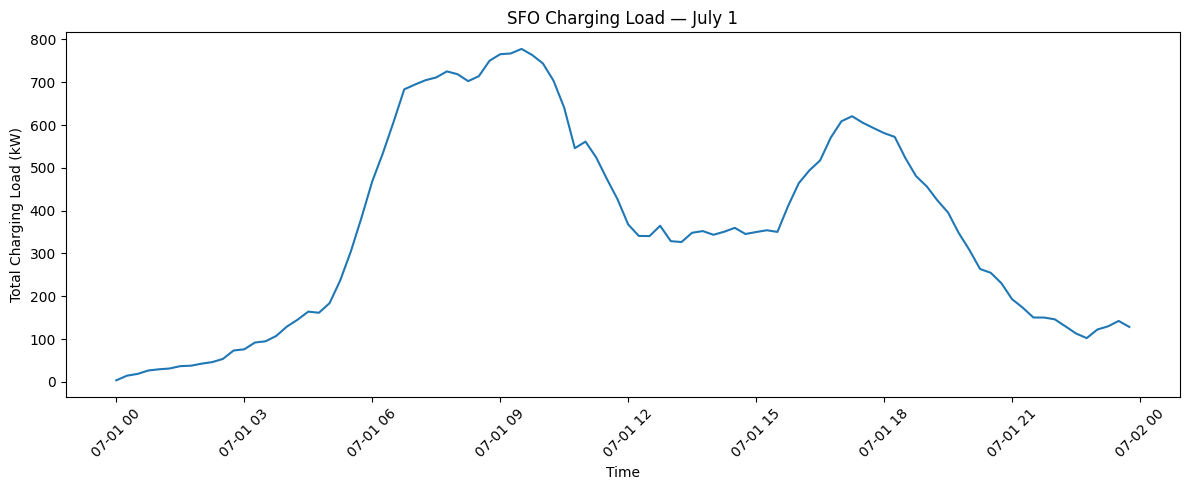

In [86]:
one_day = timeline[
    timeline["timestamp"].dt.date
    == pd.Timestamp("2026-07-01").date()
]

plt.figure(figsize=(12, 5))
plt.plot(one_day["timestamp"], one_day["load_kw"])

plt.xlabel("Time")
plt.ylabel("Total Charging Load (kW)")
plt.title("SFO Charging Load — July 1")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sanity checks

In [93]:
max_possible_kw = sum(
    port["power_kw"]
    for lot_ports in ports.values()
    for port in lot_ports
)

print("Maximum possible load:", max_possible_kw, "kW")
print("Observed peak:", timeline["load_kw"].max(), "kW")

assert timeline["load_kw"].max() <= max_possible_kw + 1e-9

Maximum possible load: 1601.6 kW
Observed peak: 802.9333333311109 kW


In [115]:
total_kwh = timeline["load_kw"].sum() * 0.25

print(f'total simulated energy: {total_kwh} kWh')


served = cars[cars["accepted"]].copy()

served["energy_delivered_kwh"] = (
    served["port_power_kw"] * served["charging_hours"]
)

car_energy_kwh = served["energy_delivered_kwh"].sum()


print(f'car energy delivered: {car_energy_kwh}')

total simulated energy: 265714.81999967137 kWh
car energy delivered: 265829.6


In [97]:
served = cars[cars["accepted"]].copy()

served["energy_delivered_kwh"] = (
    served["port_power_kw"] * served["charging_hours"]
)

expected_kwh = served["energy_delivered_kwh"].sum()

print("Timeline energy:", total_kwh)
print("Expected from cars:", expected_kwh)
print("Difference:", total_kwh - expected_kwh)

Timeline energy: 265714.81999967137
Expected from cars: 265829.6
Difference: -114.78000032861019


In [99]:
print("Rows:", len(timeline))
print("Missing timestamps:", timeline["timestamp"].isna().sum())
print("Missing loads:", timeline["load_kw"].isna().sum())
print("Negative loads:", (timeline["load_kw"] < 0).sum())

assert len(timeline) == 2976
assert timeline["timestamp"].isna().sum() == 0
assert timeline["load_kw"].isna().sum() == 0
assert (timeline["load_kw"] < 0).sum() == 0

Rows: 2976
Missing timestamps: 0
Missing loads: 0
Negative loads: 0
